In [1]:
import pickle as pk
import numpy as np
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
%matplotlib inline
import os
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
# print(platform)
# platform = 'cpu'
import jax
import jax.numpy as jnp
from jax import vmap, grad, pmap
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)

import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)

from jax import config
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import colossus 
import configobj

from base_class import base_class
from get_radial_profiles import Profiles
from get_Pkzs import get_Pkz
from get_Cls import get_Cl
from get_Xis import get_xi
from get_covs import get_cov
import matplotlib.pyplot as pl
from jax_cosmo import Cosmology
from jax_cosmo.background import angular_diameter_distance, radial_comoving_distance
from astropy import constants as const
import jax_cosmo.background as bkgrd

%matplotlib inline



# %load_ext autoreload
# %autoreload 2




/tmp/ipykernel_1318585/1555826597.py:10: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform
E0915 09:13:44.909699 1318585 cuda_dnn.cc:534] Could not create cudnn handle: CUDNN_STATUS_INTERNAL_ERROR
E0915 09:13:44.909738 1318585 cuda_dnn.cc:538] Memory usage: 98203140096 bytes free, 101468602368 bytes total.
E0915 09:13:44.909910 1318585 cuda_dnn.cc:534] Could not create cudnn handle: CUDNN_STATUS_INTERNAL_ERROR
E0915 09:13:44.909927 1318585 cuda_dnn.cc:538] Memory usage: 98203140096 bytes free, 101468602368 bytes total.


1 1


In [2]:
import yaml
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 

from deepmerge import always_merger
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
# sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(default_data)
new_data = read_yaml(abs_path_params + '/Pge/params.yaml')
# new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
merged_data = always_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)

# analysis_dict['beam_fwhm_arcmin'] = 1.4
df_nz_comoving = np.loadtxt(abs_path_data + '/pge/comoving_nz_bgs_lrg_DESIY3_key_zall.txt')
zarray_comoving = df_nz_comoving[:,0]
nz_comoving_orig = df_nz_comoving[:,1]
indsel = np.where(zarray_comoving < 0.4)[0]
nz_comoving = np.zeros_like(zarray_comoving)
nz_comoving[indsel] = nz_comoving_orig[indsel]*1.0
indsel = np.where(zarray_comoving > 0.4)[0]
nz_comoving[indsel] = nz_comoving_orig[indsel]*1.0
analysis_dict['nbar_gal_comoving_zarray'] = zarray_comoving
analysis_dict['nbar_gal_comoving_val'] = nz_comoving




from scipy.interpolate import interp1d
ks = np.geomspace(5e-2,50,15) # wavenumbers
zedges = np.array([0.1, 0.4, 0.6, 0.8,1.1])
zarray_lens = np.linspace(0.001, 1.6, 100)
nbins_lens = len(zedges) - 1

cosmo_params = sim_params_dict.get('cosmo')
cosmo_jax = Cosmology(
            Omega_c=cosmo_params['Om0'] - cosmo_params['Ob0'],
            Omega_b=cosmo_params['Ob0'],
            h=cosmo_params['H0'] / 100.,
            sigma8=cosmo_params['sigma8'],
            n_s=cosmo_params['ns'],
            Omega_k=0.,
            w0=cosmo_params['w0'],
            wa=0.
            )
scale_fac_a_array = 1.0 / (1.0 + zarray_lens)
chi_array = radial_comoving_distance(cosmo_jax, scale_fac_a_array)
dchi_dz_array = (const.c.value * 1e-3) / bkgrd.H(cosmo_jax, scale_fac_a_array)
nz_comoving_interp = interp1d(zarray_comoving, nz_comoving, fill_value=1e-20, bounds_error=False)
nz_comoving_zarray = nz_comoving_interp(zarray_lens)
nz_zarray = nz_comoving_zarray * (chi_array**2 * dchi_dz_array)
nz_zarray = nz_zarray/(np.trapz(nz_zarray, zarray_lens))
nz_lens = {}
for jb in range(nbins_lens):
    nz_jb = np.zeros_like(nz_zarray)
    indsel = np.where((zarray_lens > zedges[jb]) & (zarray_lens < zedges[jb+1]))[0]
    nz_jb[indsel] = nz_zarray[indsel]
    norm_val = np.trapz(nz_jb, zarray_lens)
    nz_jb = nz_jb/norm_val
    nz_lens[jb] = nz_jb

nz_info_dict = {}
nz_info_dict['z_array_lens'] = zarray_lens
nz_info_dict['nbins_lens'] = nbins_lens
for ji in range(nz_info_dict['nbins_lens']):
    nz_info_dict['nz'+str(ji)] = np.maximum(nz_lens[ji], 1e-10)
analysis_dict['nz_lens_info_dict'] = nz_info_dict


from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/forecast/lsst_simulate_Y1.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 5
for ji in range(nz_info_dict['nbins']):
    nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-10)
analysis_dict['nz_source_info_dict'] = nz_info_dict
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])

analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]


analysis_dict['k_array_survey'] = jnp.array(ks / (sim_params_dict['cosmo']['H0']/100.))

# lmin, lmax, dl_log_array = 80.0, 8800.0, 0.23025851
# l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
# dl_array = l_array_all[1:] - l_array_all[:-1]
# l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
# halo_params_dict['ell_array'] = jnp.array(l_array_survey)
# analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
# analysis_dict['dl_array_survey'] = jnp.array(dl_array)



lmin, lmax, dl_log_array = 10.0, 61000.0, 0.23025851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)


analysis_dict['yy_noise_ell_fname'] = os.path.abspath(abs_path_data + '/pge/Noise_fid_yy_beamed_1p4arcmin.txt')

Ngals_bins = []
Vol_Gpc3 = []
Vol_Mpch3_uw = []
z_cens = []
P0 = 9e3
fsky_DESIxDESI = analysis_dict['fsky_gg']
for jb in range(nbins_lens):
    nz_jb_only = np.copy(nz_comoving_zarray)
    indsel = np.where((zarray_lens < zedges[jb]) | (zarray_lens > zedges[jb+1]))[0]
    nz_jb_only[indsel] = 0.0
    nz_integrate = np.trapz(nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)

    ntot_jb = nz_integrate*4*np.pi*fsky_DESIxDESI
    Ngals_bins.append(ntot_jb)

    zmean = np.trapz(zarray_lens*nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)/nz_integrate
    z_cens.append(zmean)

    fsky_nz = np.ones_like(zarray_lens)
    fsky_nz[indsel] = 0.0
    fsky_nz_desi = fsky_nz * (nz_jb_only*P0/(1 + nz_jb_only*P0))**2
    h3 = (sim_params_dict['cosmo']['H0'] / 100.0)**3
    Vol_Gpc3_comoving = 4*np.pi*fsky_DESIxDESI*np.trapz(fsky_nz * (chi_array**2)*dchi_dz_array, zarray_lens)/(h3 * 1e9)  
    Vol_Mpch3_uw.append(Vol_Gpc3_comoving * (h3 * 1e9)) 
    Vol_Gpc3_comoving_desi = 4*np.pi*fsky_DESIxDESI*np.trapz(fsky_nz_desi * (chi_array**2)*dchi_dz_array, zarray_lens)/(h3 * 1e9)   

    Vol_Gpc3.append(Vol_Gpc3_comoving_desi)
    print(zedges[jb], zedges[jb+1], 'Total galaxies = {:.2f}'.format(ntot_jb), ' Vol:', Vol_Gpc3_comoving_desi, ' Vol UW:', Vol_Gpc3_comoving)
    # print('Bin {}: Total galaxies = {:.2f}'.format(jb, ntot_jb))
    

Ngals_bins, Vol_Gpc3, z_cens, Vol_Mpch3_uw = np.array(Ngals_bins), np.array(Vol_Gpc3), np.array(z_cens), np.array(Vol_Mpch3_uw)
    
    # Ngals_bins = 3.33*np.array([506905, 771875, 859824])
analysis_dict['nbar_lens_bins'] = Ngals_bins/(analysis_dict['fsky_gg']*41253*(60**2))

analysis_dict['symbolic_pk'] = True
analysis_dict['symbolic_hmf'] = True

analysis_dict['beam_fwhm_arcmin'] = 1.6

# analysis_dict['symbolic_pk'] = False
# analysis_dict['symbolic_hmf'] = False





E0915 09:12:21.016433 1300253 cuda_dnn.cc:534] Could not create cudnn handle: CUDNN_STATUS_INTERNAL_ERROR
E0915 09:12:21.016607 1300253 cuda_dnn.cc:538] Memory usage: 98266054656 bytes free, 101468602368 bytes total.
E0915 09:12:21.017899 1300253 cuda_dnn.cc:534] Could not create cudnn handle: CUDNN_STATUS_INTERNAL_ERROR
E0915 09:12:21.017951 1300253 cuda_dnn.cc:538] Memory usage: 98266054656 bytes free, 101468602368 bytes total.


XlaRuntimeError: FAILED_PRECONDITION: DNN library initialization failed. Look at the errors above for more details.

In [4]:
base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)

# bg_z_array = Pkz_test.bg_kz_mat[5,indsel_chi2]
# nbar_z_array = Pkz_test.nbarz[indsel_chi2]

# print(bg_z_array, nbar_z_array)




2025-09-15 09:06:11.181507: W external/xla/xla/service/gpu/ir_emitter_unnested.cc:1180] Unable to parse backend config for custom call: Could not convert JSON string to proto: : Root element must be a message.
Fall back to parse the raw backend config str.
2025-09-15 09:06:11.181574: W external/xla/xla/service/gpu/ir_emitter_unnested.cc:1180] Unable to parse backend config for custom call: Could not convert JSON string to proto: : Root element must be a message.
Fall back to parse the raw backend config str.


: 

In [2]:
import pickle as pk
df = pk.load(open('Mh_Mstar_v0.pk','rb'))
print(df.keys())




dict_keys(['Mstar', 'Mh_Mstar'])


Text(0, 0.5, '$M_h$')

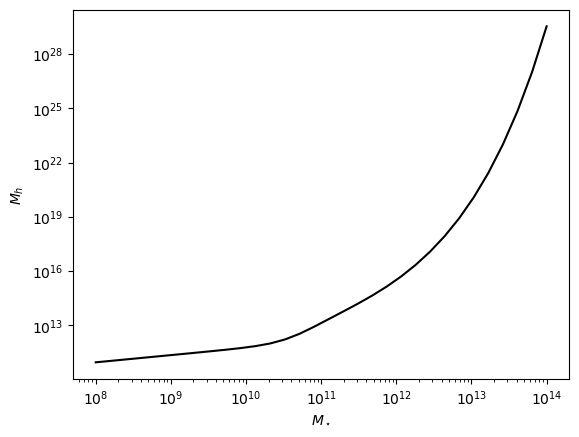

In [4]:
import matplotlib.pyplot as pl
pl.figure()
pl.loglog(df['Mstar'], df['Mh_Mstar'][:,0], 'k-')
pl.xlabel(r'$M_\star$')
pl.ylabel(r'$M_h$')


In [5]:
from tqdm import tqdm
from base_class import get_vmapped_func, get_vmapped_func_warg, EmptyCallable
from jax import jit, vmap
import interpax
import jax.scipy.integrate as jsi
from tqdm import tqdm
from colossus.cosmology import cosmology as cosmology_colossus
from colossus.halo import mass_defs
from colossus.halo import concentration
from scipy.interpolate import interp1d

vmapped_func = get_vmapped_func_warg(Pkz_test.get_P_1h, 2, 4)
Pyy_1h_kz_mat = vmapped_func(jnp.arange(Pkz_test.nk), jnp.arange(Pkz_test.nz), 3, 3).T
Pyy_2h_kz_mat = Pkz_test.by_kz_mat * Pkz_test.by_kz_mat * Pkz_test.plin_kz_mat
Pyy_tot_mat = Pyy_1h_kz_mat + Pyy_2h_kz_mat

print(profiles_test.fstar_tot_mat[10,:])
# Bl_array = jnp.exp(-1. * Pkz_test.ell_array * (Pkz_test.ell_array + 1) * (Pkz_test.sig_beam ** 2) / 2.)
# Bl_mat = Bl_array[:, None]

@jit
def get_P_lz(jl, jz, Pk_mat):
    ell = base_test.ell_array[jl]
    chi_z = base_test.chi_array[jz]
    k_ell = (ell + 0.5)/jnp.clip(chi_z, 1.0)
    Pkz_ell = jnp.exp(jnp.interp(jnp.log(k_ell), jnp.log(base_test.kPk_array), jnp.log(Pk_mat[:,jz])))
    return Pkz_ell

vmapped_func = get_vmapped_func_warg(get_P_lz, 2, 3)
Pkyy_lz_mat = vmapped_func(jnp.arange(base_test.nell), jnp.arange(base_test.nz), Pyy_tot_mat).T

# Pkyy_lz_mat = Pkyy_lz_mat * (Bl_mat**2)
logPkyylz_2d_interp = interpax.Interpolator2D(jnp.log(base_test.ell_array), base_test.z_array, jnp.log(Pkyy_lz_mat), extrap=True)        

@jit
def get_Cl_tot(jl):
    Pk = jnp.exp(logPkyylz_2d_interp(jnp.log(base_test.ell_array[jl]), base_test.z_array_for_Cls))
    Wy_array = (1.0 / (1.0 + base_test.z_array_for_Cls))

    prefac = Wy_array / (base_test.chi_array_for_Cls**2)
    fx = prefac * prefac  * (base_test.chi_array_for_Cls ** 2) * base_test.dchi_dz_array_for_Cls * Pk
    return jsi.trapezoid(fx, x=base_test.z_array_for_Cls)     

Cl_yy = vmap(get_Cl_tot)(jnp.arange(base_test.nell))
fach = 1e12*((base_test.ell_array)*(base_test.ell_array + 1) / (2 * np.pi))
# if np.abs((fach*Cl_yy)[np.argmin(np.abs(base_test.ell_array - 3000))] - 1e12*3.42*fac)/(1e12*3.42*fac) < 0.2:
jz_fb = 50
if True:

    cosmop = sim_params_dict['cosmo']
    params = {'w0':-1.0 ,'flat': True, 'H0': cosmop['H0'], 'Om0': cosmop['Om0'], 'Ob0': cosmop['Ob0'], 'sigma8':cosmop['sigma8'] ,'ns': cosmop['ns']}
    cosmology_colossus.addCosmology('myCosmo', params)
    cosmology_colossus.setCosmology('myCosmo')
    cosmo_colossus = cosmology_colossus.setCosmology('myCosmo')
    
    h = params['H0']/100.
    z = z_array[jz_fb]
    M500c_min_wh = 6e13*h
    M500c_max_wh = 2e14*h
    c500c_min_wh = concentration.concentration(M500c_min_wh, '500c', z, model = 'bhattacharya13')
    c500c_max_wh = concentration.concentration(M500c_max_wh, '500c', z, model = 'bhattacharya13')
    M200c_min_wh, _, _ = mass_defs.changeMassDefinition(M500c_min_wh, c500c_min_wh, z, '500c', '200c')
    M200c_max_wh, _, _ = mass_defs.changeMassDefinition(M500c_max_wh, c500c_max_wh, z, '500c', '200c')
    
    halo_params_dict['lg10_Mmin'] = np.log10(M200c_min_wh)
    halo_params_dict['lg10_Mmax'] = np.log10(M200c_max_wh)
    
    halo_params_dict['zmin'] = z
    halo_params_dict['zmax'] = z + 0.01
    halo_params_dict['nz'] = 3

    halo_params_dict['nr'] = 32
    
    base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
    profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
    
    
    M200c_array = profiles_test.M_array
    conc_array = profiles_test.conc_Mz_mat[0,:]
    M500c_array, R500c_array, _ = mass_defs.changeMassDefinition(M200c_array, conc_array, z, '200c', '500c')
    R500c_array /= 1000.
    
    rho_baryon_mat = profiles_test.rho_gas_mat + profiles_test.rho_cga_mat + ((profiles_test.fstar_sat_mat/profiles_test.fclm_mat)[None,:,:])*profiles_test.rho_clm_mat
    rho_tot_mat = profiles_test.rho_dmb_mat
    rho_baryon_mat_z0 = rho_baryon_mat[:,0,:]
    rho_tot_mat_z0 = rho_tot_mat[:,0,:]
    
    fb_array = np.zeros(len(M500c_array))
    for jM in range(len(M500c_array)):
            r500_jM = R500c_array[jM]
            r_array_jM = np.logspace(-3, np.log10(r500_jM), 100)
            rho_baryon_jM = rho_baryon_mat_z0[:,jM]
            interprho = interp1d(np.log(profiles_test.r_array), np.log(rho_baryon_jM), fill_value='extrapolate')
            rhob_jM = np.exp(interprho(np.log(r_array_jM)))
            rhob_int_jM = np.trapezoid(4 * np.pi * r_array_jM**3 * rhob_jM, np.log(r_array_jM))
    
    
            rho_tot_jM = rho_tot_mat_z0[:,jM]
            interprho = interp1d(np.log(profiles_test.r_array), np.log(rho_tot_jM), fill_value='extrapolate')
            rhotot_jM = np.exp(interprho(np.log(r_array_jM)))
            rhotot_int_jM = np.trapezoid(4 * np.pi * r_array_jM**3 * rhotot_jM, np.log(r_array_jM))
    
            fb_array[jM] = rhob_int_jM/rhotot_int_jM
    
    fb_bar = np.trapezoid(fb_array * profiles_test.hmf_Mz_mat[0, :], x=np.log(profiles_test.M_array))/np.trapezoid(profiles_test.hmf_Mz_mat[0, :], x=np.log(profiles_test.M_array))
    fb_bar_norm = fb_bar/(cosmop['Ob0']/cosmop['Om0'])

    # fb_norm_all_samp.append(fb_bar_norm)
    

    # print(map_ind, z, fb_bar_norm, sim_params_dict)
    print(z, fb_bar_norm, sim_params_dict)


    # Cl_yy_all_samp.append(Cl_yy)
    # ratio = Pkz_test.Pmm_dmb_tot_mat[:,0]/Pkz_test.Pmm_nfw_tot_mat[:,0]    
    # Pmm_ratio_all_samp.append(savitzky_golay(ratio, 19, 3))





[0.00263194 0.00631108 0.00817349 0.00856857 0.00800747 0.00721805
 0.00631196 0.00551291 0.00486428 0.00439163 0.00416523 0.00416312
 0.00440952 0.00488845 0.00562514 0.00658471 0.00781032 0.00926291
 0.01098683 0.01292896 0.01516884 0.01759513 0.02032782 0.02329465]
0.5 0.2603345909673316 {'cosmo': {'flat': True, 'H0': 67.2, 'Om0': 0.3, 'Ob0': 0.048, 'sigma8': 0.8, 'ns': 0.96, 'w0': -1.0}, 'init_power': True, 'nfw_trunc': True, 'epsilon_rt': 4.0, 'theta_ej_0': 2.0, 'log10_Mstar0_theta_ej': 16.0, 'nu_theta_ej_M': -0.33, 'nu_theta_ej_z': -1.22, 'theta_co_0': 0.05, 'log10_Mstar0_theta_co': 16.0, 'nu_theta_co_M': 0.0, 'nu_theta_co_z': 0.0, 'mu_beta': 0.0762, 'log10_Mstar0': 14.0, 'log10_Mc0': 13.75, 'nu_z': 0.0, 'nu_M': 0.0, 'gamma_rhogas': 2.0, 'delta_rhogas': 7.0, 'a_zeta': 0.3, 'n_zeta': 2.0, 'alpha_nt': 0.05, 'beta_nt': 0.5, 'n_nt': 0.3, 'log10M1_fshmr': 12.55, 'log10M1_a_fshmr': 0.38, 'log10Mstar0_fshmr': 10.72, 'log10Mstar0_a_fshmr': 0.55, 'beta_fshmr': 0.4, 'beta_a_fshmr': 0.2, 'd

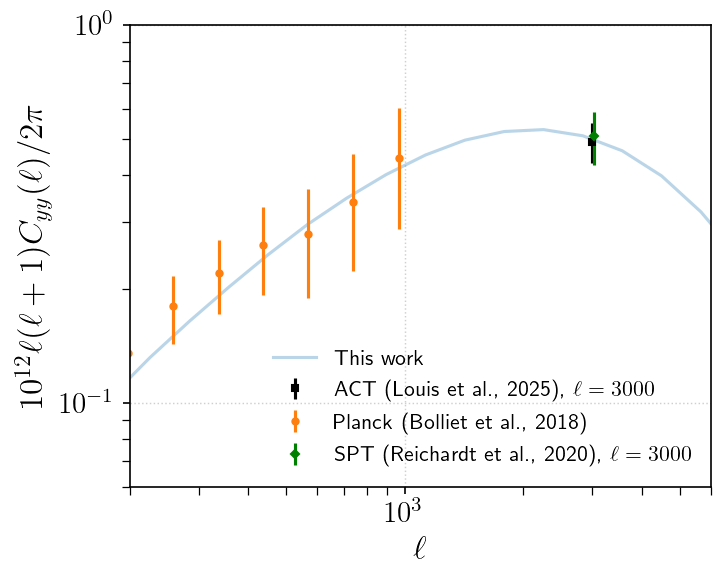

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
from astropy import constants as const
from astropy import units as u

def get_Tcmb_K():
    Tcmb = 2.7255
    return Tcmb

def tsz_freq(nu):
    #Input frequency in GHz, output conversion from y to \Delta T/T_CMB
    #nu in GHz
    #See carlstrom paper: https://ned.ipac.caltech.edu/level5/Sept05/Carlstrom/Carlstrom2.html
    T_cmb = get_Tcmb_K()*u.K
    x = (const.h*nu*(1.0e9*1./u.s)/(const.k_B*T_cmb)).to('').value
    f_x = x*((np.exp(x) + 1.)/(np.exp(x) - 1.)) - 4.
    return f_x

fac = (1e-12)/(((get_Tcmb_K())*tsz_freq(150))**2)

fnameDl_yy_planck = np.loadtxt(abs_path_data + '/DESxACT/Cl_yy_data/bolliet_18_cl_yy_mean.txt')
ell = fnameDl_yy_planck[:,0]
Dl_yy_planck = fnameDl_yy_planck[:,1] * 1e-12

fnameDl_yy_planck = np.loadtxt(abs_path_data + '/DESxACT/Cl_yy_data/bolliet_18_cl_yy_meanp1sig.txt')
err_Dlyy_planck = (fnameDl_yy_planck[:,1] * 1e-12 - Dl_yy_planck)


act_Dl_ratio = np.loadtxt(abs_path_data + '/DESxACT/Cl_yy_data/ACT_DR6_Dlyy_ratio_3000.txt')
ell_act_Dl_ratio = act_Dl_ratio[:,0]
Dl_ratio_act = act_Dl_ratio[:,1]

# fac = (1e-12)/(((get_Tcmb_K())*tsz_freq(150))**2)


plt.figure(figsize=(5, 4), dpi=150)

# Fill region with transparency
# plt.fill_between(M_array, Ymin, Ymax, alpha=0.3, color='tab:blue', label='This Work')
plt.plot(base_test.ell_array, fach*Cl_yy, color='tab:blue', alpha=0.3, label='This work')
# plt.fill_between(M_array, Ymin_2sigma, Ymax_2sigma, alpha=0.2, color='tab:blue')

# Plot main curve with improved styling
vljv,vljvp, vljvn = 3.3*fac,(3.3+0.4)*fac,(3.3-0.4)*fac
plt.errorbar(np.array([3000.]),1e12*np.array([vljv]),yerr=1e12*np.array([[vljv-vljvn,vljvp - vljv]]).T,ls='',marker='s',ms='3',color='black',label=r'ACT (Louis et al., 2025), $\ell=3000$')
# plt.plot(ell_act_Dl_ratio, 1e12*Dl_ratio_act*3.3*fac, ls='--', color='black', label='ACT (Louis et al., 2025) bestfit')
plt.errorbar(ell, 1e12*Dl_yy_planck, yerr=1e12*err_Dlyy_planck, ls='', marker='o', ms='3', color='tab:orange', label='Planck (Bolliet et al., 2018)')
vljv,vljvp, vljvn = 3.42*fac,(3.42+0.54)*fac,(3.42-0.54)*fac
plt.errorbar([3024],[1e12*vljv],yerr=1e12*np.array([[vljv-vljvn,vljvp - vljv]]).T,ls='',marker='D',ms='3',color='green',label=r'SPT (Reichardt et al., 2020), $\ell=3000$')



# Log scales for better visualization
plt.xscale('log')
plt.yscale('log')

# Axis labels with LaTeX-style formatting
plt.xlabel(r'$\ell$', fontsize=16)
plt.ylabel(r'$10^{12} \ell (\ell + 1) C_{yy}(\ell)/2\pi$', fontsize=16)

# Improved axis limits
plt.ylim(1e12*6e-14, 1e11*1e-11)
plt.xlim(2e2, 6e3)

# Improved legend with frame and better positioning
plt.legend(fontsize=10.5, frameon=False, loc='best')

# Better tick formatting for readability
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tick_params(axis='both', which='minor', labelsize=12, length=4)

# Grid with transparency for better visualization
# plt.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.6)
plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)

# Save figure with high quality
# sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# plt.savefig(sdir + 'Dl_yy_infer.pdf', bbox_inches='tight', dpi=300) 

plt.show()




In [8]:
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)
xis_test = get_xi(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cl_obj=Cls_test)


from base_class import get_vmapped_func, get_vmapped_func_warg, EmptyCallable
import interpax
import jax.scipy.integrate as jsi
from mcfitjax.transforms import Hankel

Bl_mat = (jnp.exp(-1. * Pkz_test.ell_array * (Pkz_test.ell_array + 1) * (Pkz_test.sig_beam ** 2) / 2.))[:, None]
def get_xi_pred(Pk_mat, isym, ismm_p, ismm_m):
    # Convert the 3D power spectra multipole space Pkz_ell:
    vmapped_func = get_vmapped_func_warg(Cls_test.get_P_lz, 2, 3)
    Pk_lz_mat = vmapped_func(jnp.arange(Pkz_test.nell), jnp.arange(Pkz_test.nz), Pk_mat).T    
    if isym:
        Pk_lz_mat = Pk_lz_mat * Bl_mat
    logPklz_2d_interp = interpax.Interpolator2D(jnp.log(Pkz_test.ell_array), Pkz_test.z_array, jnp.log(Pk_lz_mat), extrap=True)        
    
    def get_Cl_tot(jl, jb1, jb2, probe1, probe2): 
        # Handle the first probe condition
        def compute_prefac(probe, jb):
            conditions = [
                (probe == 0, (1. + Cls_test.mult_shear_bias_array[jb]) * (Cls_test.Wk_mat[jb] / (Cls_test.chi_array_for_Cls**2))),
                (probe == 3, Cls_test.Wy_array / (Cls_test.chi_array_for_Cls**2)),
            ]
            
            prefac = jnp.nan
            for condition, value in conditions:
                prefac = jnp.where(condition, value, prefac)
            return prefac
    
        # Compute prefactors for probe1 and probe2
        prefac_for_uk1 = compute_prefac(probe1, jb1)
        prefac_for_uk2 = compute_prefac(probe2, jb2)        
    
        Pk = jnp.exp(logPklz_2d_interp(jnp.log(Cls_test.ell_array[jl]), Cls_test.z_array_for_Cls))
        fx = prefac_for_uk1 * prefac_for_uk2  * (Cls_test.chi_array_for_Cls ** 2) * Cls_test.dchi_dz_array_for_Cls * Pk
        return jsi.trapezoid(fx, x=Cls_test.z_array_for_Cls)  
        
    
    if isym:
        vmapped_func = get_vmapped_func_warg(get_Cl_tot, 2, 5)
        Cl_mat = vmapped_func(jnp.arange(Cls_test.nell), jnp.arange(Cls_test.nbins), 0, 0, 3).T
        theta_out, xi_out = (Hankel(Cls_test.ell_array, nu=2, q=1.0, nx=Cls_test.nell, lowring=True)(Cl_mat, axis=0, extrap=False))
        theta_out_arcmin = theta_out * (180. / jnp.pi) * 60.
        gty_tot_mat = jnp.array(xi_out * (1 / (2 * jnp.pi)))
        
        def interp_gty_theta(jt, jb):
            gty_out = jnp.exp(jnp.interp(jnp.log(xis_test.angles_data_array[jt]), jnp.log(theta_out_arcmin), jnp.log(gty_tot_mat[:, jb])))
            return gty_out

        xi_out_mat = get_vmapped_func(interp_gty_theta, 2)(jnp.arange(xis_test.nt_out), jnp.arange(xis_test.nbins)).T
        
    
    else:
        vmapped_func = get_vmapped_func_warg(get_Cl_tot, 3, 5)
        Cl_mat = vmapped_func(jnp.arange(Cls_test.nell), jnp.arange(Cls_test.nbins), jnp.arange(Cls_test.nbins), 0, 0).T
        if ismm_p:
            theta_out, xi_out = (Hankel(xis_test.ell_array, nu=0, q=1.0, nx=xis_test.nell, lowring=True)(Cl_mat, axis=0, extrap=False))        
        if ismm_m:
            theta_out, xi_out = (Hankel(xis_test.ell_array, nu=4, q=1.0, nx=xis_test.nell, lowring=True)(Cl_mat, axis=0, extrap=False))        
        theta_out_arcmin = theta_out * (180. / jnp.pi) * 60.
        xi_tot_mat = jnp.array(xi_out * (1 / (2 * jnp.pi)))
        def interp_xipm_theta(jb1, jb2):
            xi_out = jnp.exp(jnp.interp(jnp.log(xis_test.angles_data_array), jnp.log(theta_out_arcmin), jnp.log(xi_tot_mat[:, jb1,jb2])))
            return xi_out
        xi_out_mat = get_vmapped_func(interp_xipm_theta, 2)(jnp.arange(xis_test.nbins), jnp.arange(xis_test.nbins)).T

    return xi_out_mat
    

gty_1h_ym = get_xi_pred(Pkz_test.Pym_1h_kz_mat, 1, 0, 0)
gty_2h_ym = get_xi_pred(Pkz_test.Pym_2h_kz_mat, 1, 0, 0)

deproj_to_true_y_file = {
    'None': 'ilc_SZ_yy',
    'cib_1p0': 'ilc_SZ_deproj_cib_1.0_10.7_yy',
    'cib_1p2': 'ilc_SZ_deproj_cib_1.2_10.7_yy',
    'cib_1p4': 'ilc_SZ_deproj_cib_1.4_10.7_yy',
    'cib_1p6': 'ilc_SZ_deproj_cib_1.6_10.7_yy',
    'cib_1p7': 'ilc_SZ_deproj_cib_1.7_10.7_yy',
    'cib_1p8': 'ilc_SZ_deproj_cib_1.8_10.7_yy',
    'cib_2p0': 'ilc_SZ_deproj_cib_2.0_10.7_yy',
    'cib_1p0_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.0_10.7_yy',
    'cib_1p2_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.2_10.7_yy',
    'cib_1p4_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.4_10.7_yy',
    'cib_1p6_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.6_10.7_yy',
    'cib_1p7_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy',
    'cib_1p8_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.8_10.7_yy',
    'cib_2p0_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_2.0_10.7_yy',
}
deproj = 'cib_1p7_dBeta'
probe = 'all'
# save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v2/')
# save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v3/')
save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v4/')
# df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}.pk', 'rb'))
# df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}_maskedPS_maskang_3_5sigma_thresh.pk', 'rb'))
df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}_maskedPS.pk', 'rb'))
cov_total = df_measure['cov_total']
xi_all = df_measure['xi_all']
theta_all = df_measure['theta_all']
bin1_all = df_measure['bin1_all']
bin2_all = df_measure['bin2_all']
cov_total = jnp.array(cov_total)
data_vec = jnp.array(xi_all)

# save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v2/')
# df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}.pk', 'rb'))
# df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}_maskedPS_maskang_3_5sigma_thresh.pk', 'rb'))
# cov_total = df_measure['cov_total']
# xi_all = df_measure['xi_all']
# theta_all = df_measure['theta_all']
# cov_total = jnp.array(cov_total)
# data_vec = jnp.array(xi_all)

df_cs = fits.open(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate_newbins.fits') 
bin1_vals =  df_cs['xip'].data['BIN1'][::20]
bin2_vals =  df_cs['xip'].data['BIN2'][::20]
biny_vals = np.array([1,2,3,4])
ang_vals = df_cs['xip'].data['ANG'][0:20]



cov_total = jnp.array(cov_total)
data_vec = jnp.array(xi_all)


gty_dv = data_vec[:80]
sig_gty_dv = np.sqrt(np.diag(cov_total))[:80]

xip_dv = data_vec[80:280]
sig_xip_dv = np.sqrt(np.diag(cov_total))[80:280]
bin1_xip_dv = df_cs['xip'].data['BIN1']
bin2_xip_dv = df_cs['xip'].data['BIN2']

xim_dv = data_vec[280:]
sig_xim_dv = np.sqrt(np.diag(cov_total))[280:]
bin1_xim_dv = df_cs['xim'].data['BIN1']
bin2_xim_dv = df_cs['xim'].data['BIN2']

if probe == 'xip_xim':
    cov_total = cov_total[80:, 80:]
    data_vec = data_vec[80:]
elif probe == 'gty':
    cov_total = cov_total[:80, :80]
    data_vec = data_vec[:80]

fname = abs_path_data + '/DESxACT/scale_cuts_xipm_y3_gty_fid.ini'
config = configobj.ConfigObj(fname)
sc_xipm = config['shear-shear']
sc_gty = config['shear-tsz']



def process_indices(num, bin1_vals, bin2_vals, angle_ranges, offset, probe, angle_type, do_scalecuts):
    indices, indrm = [], []
    for js in range(num):
        binv, thetav = divmod(js, 20)
        bin1, bin2 = (bin1_vals[binv] - 1, bin2_vals[binv] - 1) if angle_type != 'gty' else (None, None)
        if do_scalecuts:
            sc_min, sc_max = map(float, angle_ranges[binv].split())
        else:
            sc_min, sc_max = 1e-3, 999.0
        if sc_min < ang_vals[thetav] < sc_max:
            indices.append([int(thetav), int(bin1), int(bin2)] if bin1 is not None else [int(thetav), int(binv)])
        elif probe in [angle_type, 'all']:
            indrm.append(int(offset + js))
    return jnp.array(indices, dtype=jnp.int32), jnp.array(indrm, dtype=jnp.int32)

# Process gty indices
sc_ranges_gty = [sc_gty[f'angle_range_gty_{biny}_0'] for biny in biny_vals]
index_gty, indrm_gty = process_indices(80, None, None, sc_ranges_gty, 0, probe, 'gty', False)
len_ind_gty = len(index_gty)
# Process xip indices
sc_ranges_xip = [sc_xipm[f'angle_range_xip_{bin1}_{bin2}'] for bin1, bin2 in zip(bin1_vals, bin2_vals)]
offset_xip = 80 if probe in ['gty', 'all'] else 0
index_xip, indrm_xip = process_indices(200, bin1_vals, bin2_vals, sc_ranges_xip, offset_xip, probe, 'xip_xim', False)
len_ind_xip = len(index_xip)
# Process xim indices
sc_ranges_xim = [sc_xipm[f'angle_range_xim_{bin1}_{bin2}'] for bin1, bin2 in zip(bin1_vals, bin2_vals)]
offset_xim = 280 if probe in ['gty', 'all'] else 200
index_xim, indrm_xim = process_indices(200, bin1_vals, bin2_vals, sc_ranges_xim, offset_xim, probe, 'xip_xim', False)
len_ind_xim = len(index_xim)


def get_gty_from_index(index):
    index_val = index_gty[index]
    return xis_test.gty_out_mat[index_val[0], index_val[1]]

def get_xip_from_index(index):
    index_val = index_xip[index]
    return xis_test.xip_out_mat[index_val[0], index_val[1], index_val[2]]

def get_xim_from_index(index):
    index_val = index_xim[index]
    return xis_test.xim_out_mat[index_val[0], index_val[1], index_val[2]]

gty_all = vmap(get_gty_from_index)(jnp.arange(len_ind_gty))
xip_all = vmap(get_xip_from_index)(jnp.arange(len_ind_xip))
xim_all = vmap(get_xim_from_index)(jnp.arange(len_ind_xim))







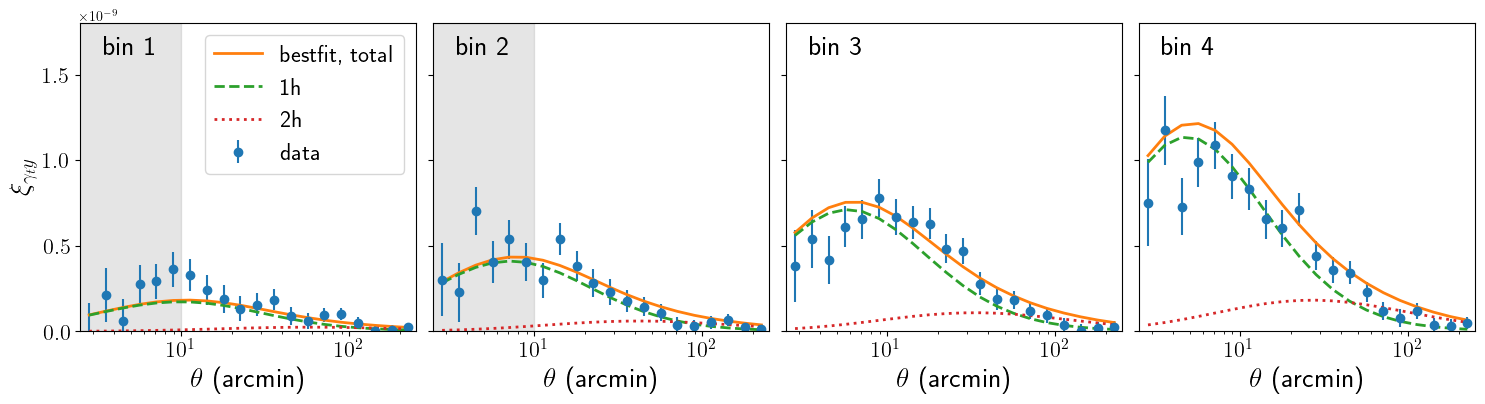

In [9]:
# make a four subplot figure:
fig, axes = pl.subplots(1, 4, figsize=(18, 4), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji in range(4):
    ax = axes[ji]
    ax.errorbar(theta_all[ji*20:(ji+1)*20], gty_dv[ji*20:(ji+1)*20], sig_gty_dv[ji*20:(ji+1)*20], label='data', ls='', marker='o')
    ax.plot(theta_all[ji*20:(ji+1)*20], gty_all[ji*20:(ji+1)*20], label='bestfit, total', lw=2)
    ax.plot(theta_all[ji*20:(ji+1)*20], gty_1h_ym[:, ji], label='1h', ls='--', lw=2)
    ax.plot(theta_all[ji*20:(ji+1)*20], gty_2h_ym[:, ji], label='2h', ls=':', lw=2)
    # ax.set_title(f'gty bin {ji+1}')
    if ji == 0:
        ax.legend(fontsize=17)
    ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.set_ylim(0, 1.8e-9)
    ax.set_xlabel(r'$\theta$ (arcmin)', fontsize=20)

    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.tick_params(axis='both', which='minor', labelsize=16)
    ax.set_xlim(2.5, 250)
    ax.text(0.07, 0.9, f'bin {ji+1}', transform=ax.transAxes, fontsize=20)
    if ji == 0:
        ax.set_ylabel(r'$\xi_{\gamma_t y}$', fontsize=20)

    if ji < 2:
        ax.axvspan(0, 10, color='gray', alpha=0.2)
    # ax.set_xlim(0, 20)
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# fig.savefig(sdir + 'gty_dv_v12.pdf', bbox_inches='tight', dpi=300)
pl.show()









In [10]:
xip_1h_ym = get_xi_pred(Pkz_test.Pmm_dmb_1h_kz_mat, 0, 1, 0)
xip_2h_ym = get_xi_pred(Pkz_test.Pmm_dmb_2h_kz_mat, 0, 1, 0)
xip_hf_ym = get_xi_pred(Pkz_test.phfit_kz_mat, 0, 1, 0)



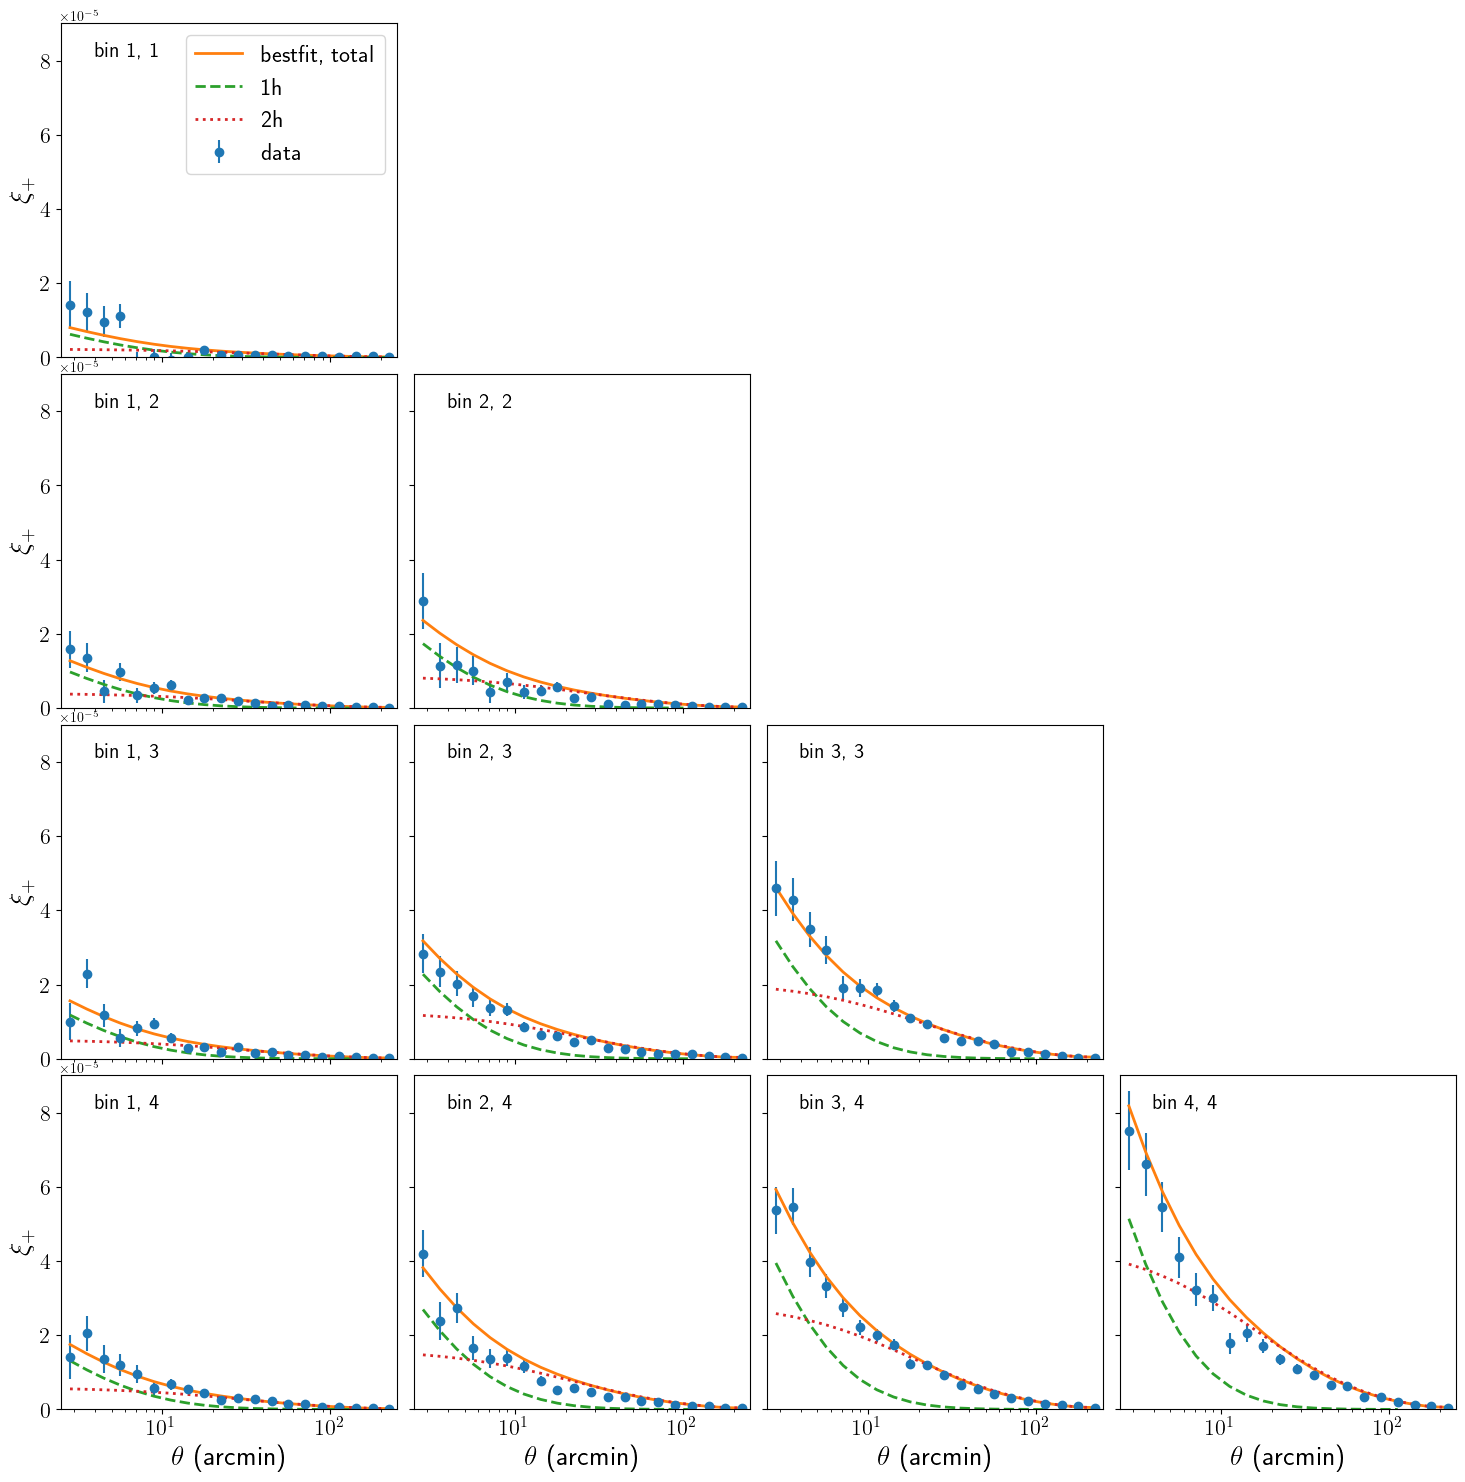

In [11]:
# make a four subplot figure:
theta_xip = theta_all[80:280]
theta_xim = theta_all[280:]
fig, axes = pl.subplots(4, 4, figsize=(18, 18), sharex=True, sharey=True)
# set spacing between suplots:
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji1 in range(4):
    for ji2 in range(4):
        if ji1 <= ji2:
            ax = axes[ji2, ji1]
            indsel = np.where((bin1_xip_dv == ji1+1) & (bin2_xip_dv == ji2+1))[0]
            ax.errorbar(theta_xip[indsel], xip_dv[indsel], sig_xip_dv[indsel], label='data', ls='', marker='o')
            ax.plot(theta_xip[indsel], xip_all[indsel], label='bestfit, total', lw=2)
            ax.plot(theta_xip[indsel], xip_1h_ym[:,ji1, ji2], label='1h', lw=2, ls='--')
            ax.plot(theta_xip[indsel], xip_2h_ym[:,ji1, ji2], label='2h', lw=2, ls=':')
            # ax.plot(theta_xip[indsel], xip_hf_ym[:,ji1, ji2], label='Halofit', lw=2, ls='-.')
            # ax.set_title(f'gty bin {ji+1}')
            if ji1 == 0 and ji2 == 0:
                # ax.set_title('xim')
                ax.legend(fontsize=17)
            ax.set_xscale('log')
            # ax.set_yscale('log')
            ax.set_ylim(0, 9e-5)
            ax.set_xlim(2.5, 250)
            ax.text(0.1, 0.9, f'bin {ji1+1}, {ji2+1}', transform=ax.transAxes, fontsize=15)
            if ji2 == 3:
                ax.set_xlabel(r'$\theta$ (arcmin)', fontsize=20)
            if ji1 == 0:
                ax.set_ylabel(r'$\xi_{+}$', fontsize=20)
            ax.tick_params(axis='both', which='major', labelsize=16)
            ax.tick_params(axis='both', which='minor', labelsize=16)

            # if ji < 2:
                # ax.axvspan(0, 10, color='gray', alpha=0.2)
        else:
            # delete the subplot:
            fig.delaxes(axes[ji2, ji1])
    # ax.set_xlim(0, 20)
# fig.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/xip_dv.png', bbox_inches='tight', dpi=300)
# sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# fig.savefig(sdir + 'xip_dv_v10.pdf', bbox_inches='tight', dpi=300)
# fig.savefig(sdir + 'xip_dv_v12.pdf', bbox_inches='tight', dpi=300)
pl.show()



In [12]:
xim_1h_ym = get_xi_pred(Pkz_test.Pmm_dmb_1h_kz_mat, 0, 0, 1)
xim_2h_ym = get_xi_pred(Pkz_test.Pmm_dmb_2h_kz_mat, 0, 0, 1)
xim_hf_ym = get_xi_pred(Pkz_test.phfit_kz_mat, 0, 0, 1)




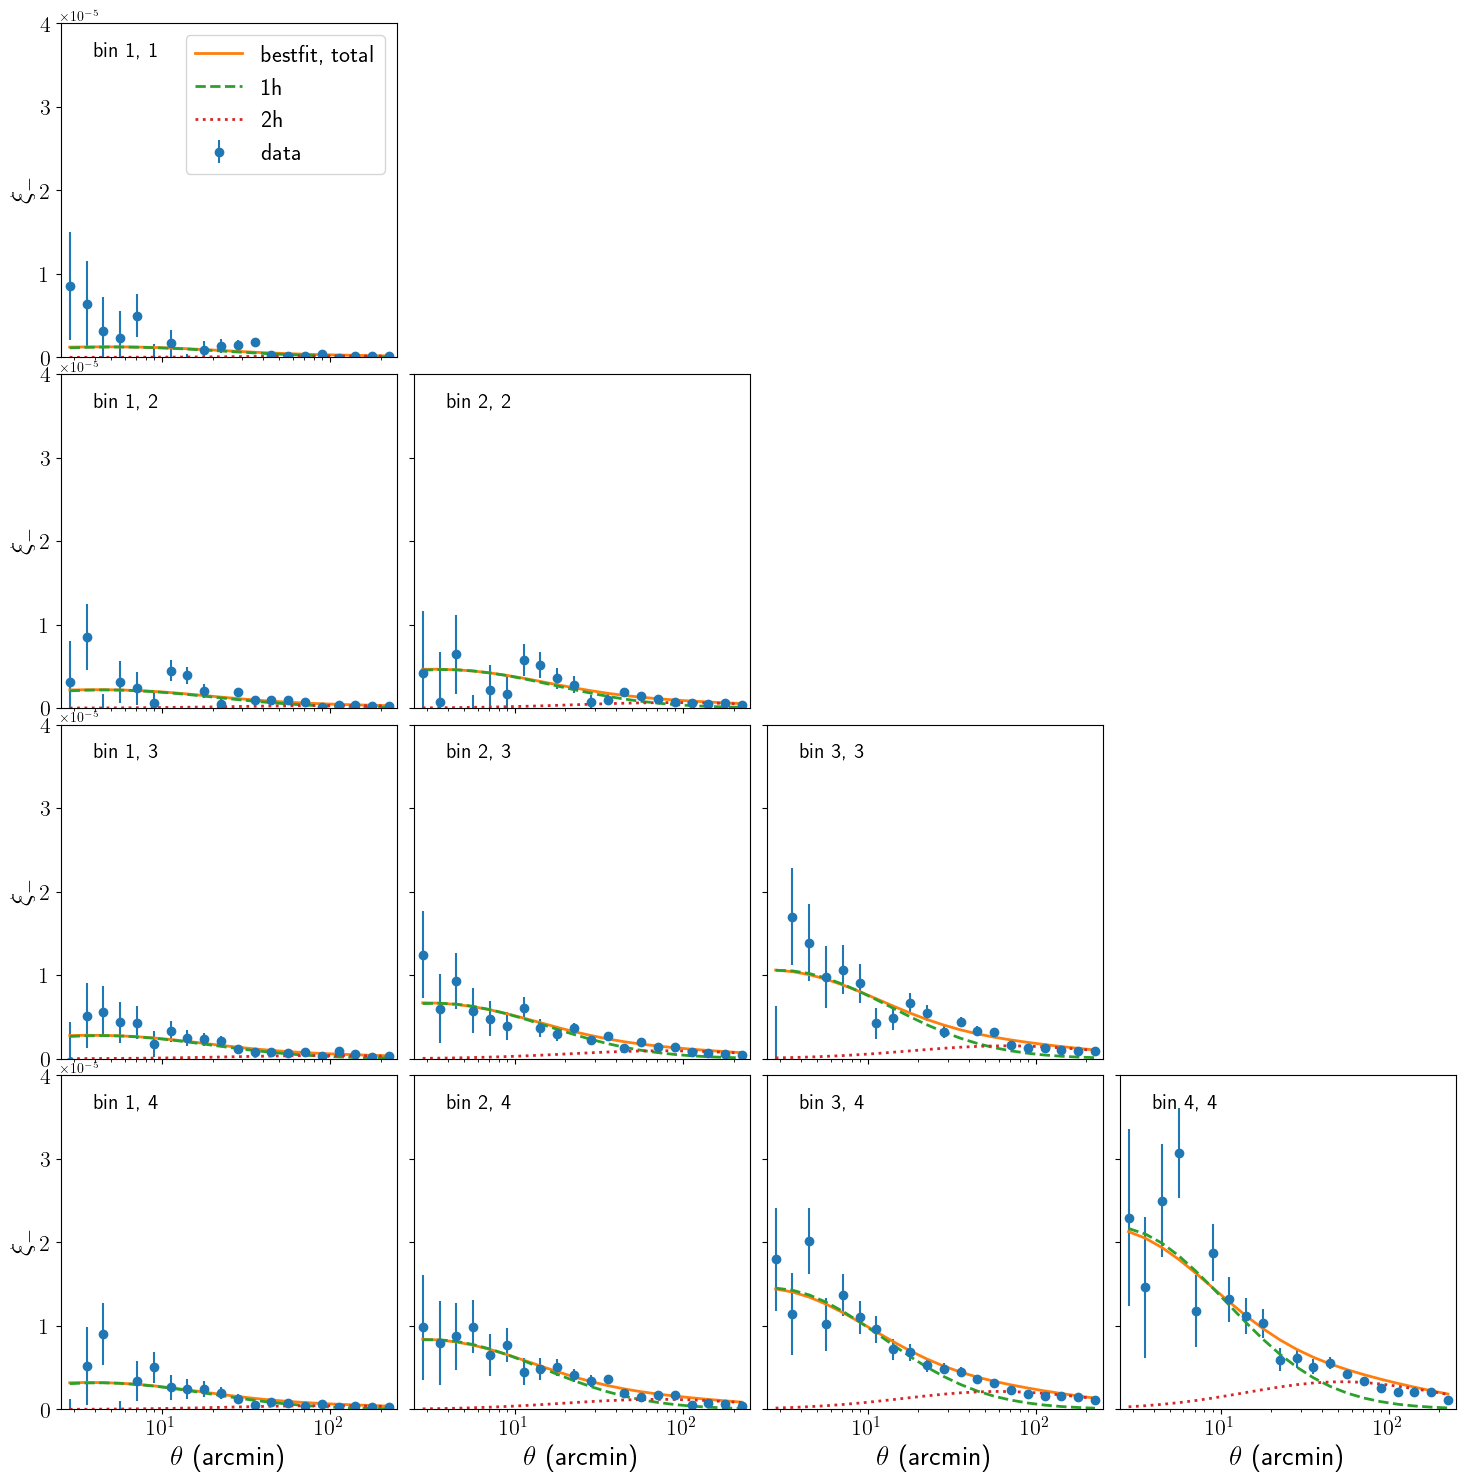

In [13]:
# make a four subplot figure:
theta_xip = theta_all[80:280]
theta_xim = theta_all[280:]
fig, axes = pl.subplots(4, 4, figsize=(18, 18), sharex=True, sharey=True)
# set spacing between suplots:
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji1 in range(4):
    for ji2 in range(4):
        if ji1 <= ji2:
            ax = axes[ji2, ji1]
            indsel = np.where((bin1_xim_dv == ji1+1) & (bin2_xim_dv == ji2+1))[0]
            ax.errorbar(theta_xim[indsel], xim_dv[indsel], sig_xim_dv[indsel], label='data', ls='', marker='o')
            ax.plot(theta_xim[indsel], xim_all[indsel], label='bestfit, total', lw=2)
            ax.plot(theta_xim[indsel], xim_1h_ym[:,ji1, ji2], label='1h', lw=2, ls='--')
            ax.plot(theta_xim[indsel], xim_2h_ym[:,ji1, ji2], label='2h', lw=2, ls=':')
            # ax.plot(theta_xim[indsel], xim_hf_ym[:,ji1, ji2], label='Halofit', lw=2, ls='-.')
            # ax.set_title(f'gty bin {ji+1}')
            if ji1 == 0 and ji2 == 0:
                # ax.set_title('xim')
                ax.legend(fontsize=17)
            ax.set_xscale('log')
            # ax.set_yscale('log')
            ax.set_ylim(0, 4e-5)
            ax.set_xlim(2.5, 250)
            ax.text(0.1, 0.9, f'bin {ji1+1}, {ji2+1}', transform=ax.transAxes, fontsize=15)
            if ji2 == 3:
                ax.set_xlabel(r'$\theta$ (arcmin)', fontsize=20)
            if ji1 == 0:
                ax.set_ylabel(r'$\xi_{-}$', fontsize=20)
            ax.tick_params(axis='both', which='major', labelsize=16)
            ax.tick_params(axis='both', which='minor', labelsize=16)

            # if ji < 2:
                # ax.axvspan(0, 10, color='gray', alpha=0.2)
        else:
            # delete the subplot:
            fig.delaxes(axes[ji2, ji1])
    # ax.set_xlim(0, 20)
# pl.yscale('log')
# fig.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/xim_dv.png', bbox_inches='tight', dpi=300)
# sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# fig.savefig(sdir + 'xim_dv_v10.pdf', bbox_inches='tight', dpi=300)
# fig.savefig(sdir + 'xim_dv_v12.pdf', bbox_inches='tight', dpi=300)
pl.show()






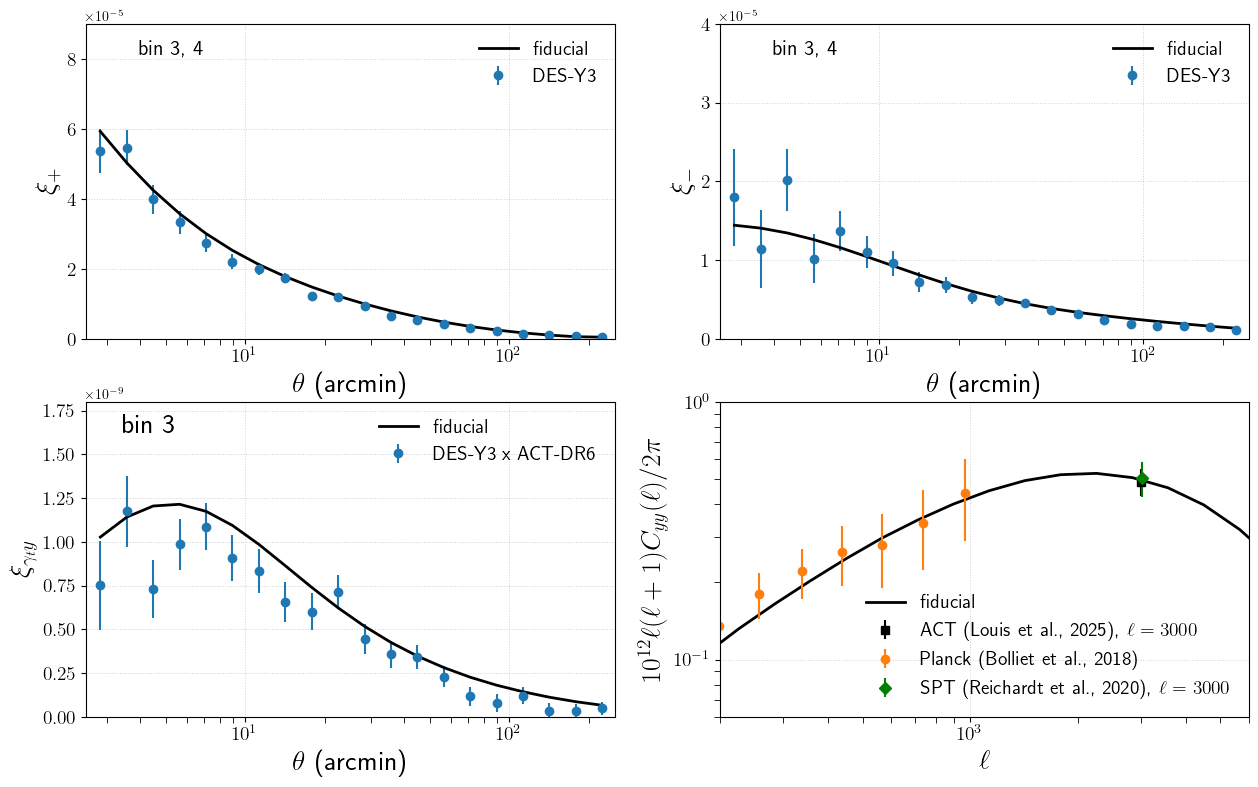

In [40]:
fig, axes = pl.subplots(2, 2, figsize=(15, 9), sharex=False, sharey=False)
# set spacing between suplots:
fig.subplots_adjust(hspace=0.2, wspace=0.2)
for ji1 in range(2):
    for ji2 in range(2):
        ax = axes[ji1, ji2]
        if ji1==0 and ji2==0:
            indsel = np.where((bin1_xip_dv == 3) & (bin2_xip_dv == 4))[0]
            ax.errorbar(theta_xip[indsel], xip_dv[indsel], sig_xip_dv[indsel], label='DES-Y3', ls='', marker='o')
            ax.plot(theta_xip[indsel], xip_all[indsel], label='fiducial', lw=2, color='k')
            # ax.plot(theta_xip[indsel], xip_1h_ym[:,ji1, ji2], label='1h', lw=2, ls='--')
            # ax.plot(theta_xip[indsel], xip_2h_ym[:,ji1, ji2], label='2h', lw=2, ls=':')
            ax.set_xscale('log')
            ax.legend(fontsize=14, frameon=False)
            ax.set_xscale('log')
            ax.set_ylim(0, 9e-5)
            ax.set_xlim(2.5, 250)
            ax.text(0.1, 0.9, f'bin 3, 4', transform=ax.transAxes, fontsize=15)
            ax.set_xlabel(r'$\theta$ (arcmin)', fontsize=20)
            ax.set_ylabel(r'$\xi_{+}$', fontsize=20)
            
        
        if ji1==0 and ji2==1:
            indsel = np.where((bin1_xim_dv == 3) & (bin2_xim_dv == 4))[0]
            ax.errorbar(theta_xim[indsel], xim_dv[indsel], sig_xim_dv[indsel], label='DES-Y3', ls='', marker='o')
            ax.plot(theta_xim[indsel], xim_all[indsel], label='fiducial', lw=2, color='k')
            # ax.plot(theta_xim[indsel], xim_1h_ym[:,ji1, ji2], label='1h', lw=2, ls='--')
            # ax.plot(theta_xim[indsel], xim_2h_ym[:,ji1, ji2], label='2h', lw=2, ls=':')
            ax.set_xscale('log')
            ax.legend(fontsize=14, frameon=False)            
            ax.set_ylim(0, 4e-5)
            ax.set_xlim(2.5, 250)
            ax.text(0.1, 0.9, f'bin 3, 4', transform=ax.transAxes, fontsize=15)
            ax.set_xlabel(r'$\theta$ (arcmin)', fontsize=20)
            ax.set_ylabel(r'$\xi_{-}$', fontsize=20)
            

        if ji1==1 and ji2==0:
            ji = 3
            ax.errorbar(theta_all[ji*20:(ji+1)*20], gty_dv[ji*20:(ji+1)*20], sig_gty_dv[ji*20:(ji+1)*20], label='DES-Y3 x ACT-DR6', ls='', marker='o')
            ax.plot(theta_all[ji*20:(ji+1)*20], gty_all[ji*20:(ji+1)*20], label='fiducial', lw=2, color='black')
            ax.set_xscale('log')
            ax.legend(fontsize=14, frameon=False)            
            ax.set_ylim(0, 1.8e-9)
            ax.set_xlabel(r'$\theta$ (arcmin)', fontsize=20)        
            ax.set_xlim(2.5, 250)
            ax.text(0.07, 0.9, f'bin 3', transform=ax.transAxes, fontsize=20)
            ax.set_ylabel(r'$\xi_{\gamma_t y}$', fontsize=20)
            
        
        if ji1==1 and ji2==1:
            ax.plot(base_test.ell_array, fach*Cl_yy, color='black', alpha=1., lw=2, label='fiducial')
            vljv,vljvp, vljvn = 3.3*fac,(3.3+0.4)*fac,(3.3-0.4)*fac
            ax.errorbar(np.array([3000.]),1e12*np.array([vljv]),yerr=1e12*np.array([[vljv-vljvn,vljvp - vljv]]).T,ls='',marker='s',color='black',label=r'ACT (Louis et al., 2025), $\ell=3000$')
            ax.errorbar(ell, 1e12*Dl_yy_planck, yerr=1e12*err_Dlyy_planck, ls='', marker='o',  color='tab:orange', label='Planck (Bolliet et al., 2018)')
            vljv,vljvp, vljvn = 3.42*fac,(3.42+0.54)*fac,(3.42-0.54)*fac
            ax.errorbar([3024],[1e12*vljv],yerr=1e12*np.array([[vljv-vljvn,vljvp - vljv]]).T,ls='',marker='D',color='green',label=r'SPT (Reichardt et al., 2020), $\ell=3000$')

            ax.set_xlabel(r'$\ell$', fontsize=20)
            ax.set_ylabel(r'$10^{12} \ell (\ell + 1) C_{yy}(\ell)/2\pi$', fontsize=20)
            ax.set_ylim(1e12*6e-14, 1e11*1e-11)
            ax.set_xlim(2e2, 6e3)
            ax.legend(fontsize=14, frameon=False, loc='best')
            ax.set_xscale('log')
            ax.set_yscale('log')

        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.tick_params(axis='both', which='minor', labelsize=12, length=4)
    
        
        ax.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)

sdir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/plots/'
pl.savefig(sdir + 'compare_data_fid.pdf', bbox_inches="tight", dpi=200)




  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 34.3 MB/s  0:00:00eta 0:00:01
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pandas]2m2/3 [pandas]


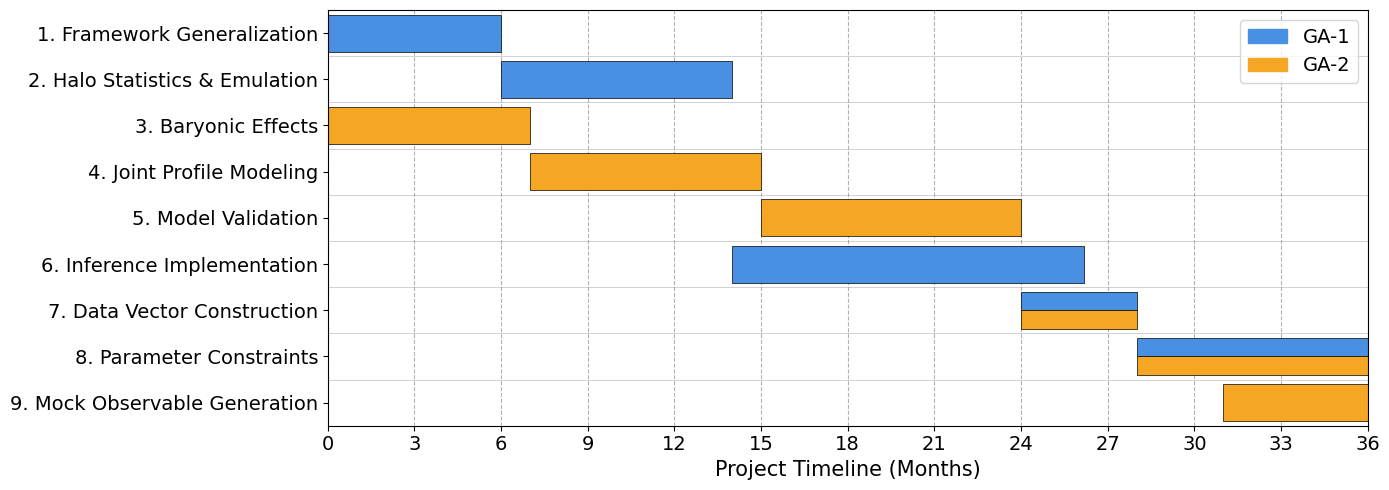

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
# change the font to something fancy:
# plt.style.use('seaborn-white')


# --- Data Setup ---
# Create a DataFrame from the project timeline
data = {
    'Task': [
        "1. Framework Generalization",
        "2. Halo Statistics & Emulation",
        "3. Baryonic Effects",
        "4. Joint Profile Modeling",
        "5. Model Validation",
        "6. Inference Implementation",
        "7. Data Vector Construction",
        "8. Parameter Constraints",
        "9. Mock Observable Generation",
    ],
    'Person': ["GA-1", "GA-1", "GA-2", "GA-2", "GA-2", "GA-1", "GA-1 & GA-2", "GA-1 & GA-2", "GA-2"],
    'Start_String': [
        "Year 1, Month 1", "Year 1, Month 7", "Year 1, Month 1", "Year 1, Month 8",
        "Year 2, Month 4", "Year 2, Month 3", "Year 3, Month 1", "Year 3, Month 5", "Year 3, Month 8"
    ],
    'Duration_Days': [180, 240, 210, 240, 270, 365, 120, 240, 180]
}
df = pd.DataFrame(data)

# --- Data Processing ---
# A helper function to convert 'Year X, Month Y' into days from project start
def convert_to_days(date_str):
    parts = date_str.replace(',', '').split()
    year = int(parts[1])
    month = int(parts[3])
    # Assuming 30 days per month for consistent plotting
    return ((year - 1) * 12 + (month - 1)) * 30

df['Start_Day'] = df['Start_String'].apply(convert_to_days)
# --- Plotting ---
# Change 1: Updated figsize
fig, ax = plt.subplots(figsize=(14, 5))

# Define colors for each student
colors = {'GA-1': '#4A90E2', 'GA-2': '#F5A623'}

# Plot each task
for idx, task in df.iterrows():
    y_pos = idx
    start = task['Start_Day']
    duration = task['Duration_Days']
    person = task['Person']

    if person == "GA-1 & GA-2":
        ax.broken_barh([(start, duration)], (y_pos - 0.4, 0.4), facecolors=colors['GA-1'], edgecolor='black', linewidth=0.5)
        ax.broken_barh([(start, duration)], (y_pos + 0.0, 0.4), facecolors=colors['GA-2'], edgecolor='black', linewidth=0.5)
    else:
        ax.broken_barh([(start, duration)], (y_pos - 0.4, 0.8), facecolors=colors[person], edgecolor='black', linewidth=0.5)

# --- Formatting ---
# Y-axis formatting
ax.set_ylim(-0.5, len(df) - 0.5)
ax.set_yticks(range(len(df)))
ax.set_yticklabels(df['Task'], fontsize=14)
# Change 2: Ensure Task 1 is at the top
ax.invert_yaxis()

# X-axis formatting
ax.set_xlabel('Project Timeline (Months)', fontsize=15)
months = np.arange(0, 37, 3) # Ticks every 3 months
ax.set_xticks(months * 30)
ax.set_xticklabels(months, fontsize=14)
ax.set_xlim(0, 36 * 30)

# Change 3: Add thin horizontal lines for each task
ax.set_axisbelow(True) # Ensure grid lines are behind bars
ax.grid(axis='x', linestyle='--', color='gray', alpha=0.6)
ax.hlines(np.arange(len(df)) + 0.5, *ax.get_xlim(), color='gray', linewidth=0.5, alpha=0.5)


#ax.set_title('3-Year Research Project Gantt Chart', fontsize=16, pad=20)

# Change 4: Place legend inside the plot in the upper right
patches = [mpatches.Patch(color=colors['GA-1'], label='GA-1'),
        mpatches.Patch(color=colors['GA-2'], label='GA-2')]
ax.legend(handles=patches, loc='upper right', fontsize=14)

# Clean up layout
plt.tight_layout()

# Save and show the plot
plt.savefig("cosmology_gantt_chart_updated.pdf", dpi=300)
plt.show()

